# Validation Dataset Preparation

## Purpose
Splits the raw champagne sales time series into a **training dataset** and a held-out **validation set**. This separation must be done before any modelling or analysis to prevent data leakage — the validation set is never seen during model development and is used only for final evaluation.

## Inputs
- `data/champagne.csv` — Full champagne monthly sales series (105 observations, Jan 1964 – Sep 1972)

## Outputs
- `data/dataset.csv` — Training portion: first 93 observations (used in all modelling notebooks)
- `data/validation.csv` — Held-out validation portion: last 12 observations (one full year)

In [1]:
import pandas as pd

## Load Raw Data

Load the full champagne sales series from CSV, parsing the `Month` column as a `DatetimeIndex`. Only the `Sales` column is selected via `.iloc[:, 0]`.

In [2]:
series = pd.read_csv('data/champagne.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Visual Inspection

Plot the complete time series to confirm it loaded correctly and to observe the overall structure before splitting.

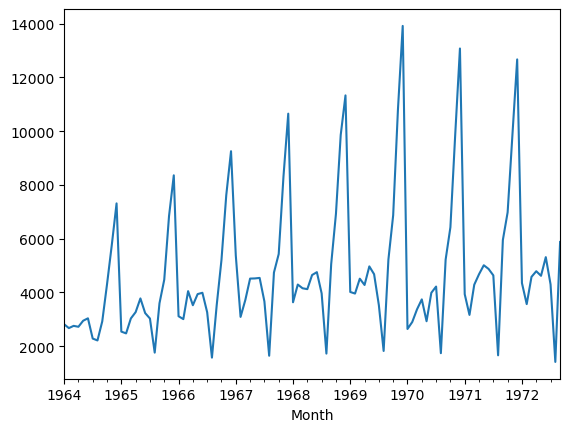

In [3]:
series.plot();

## Split and Save Training Data

Reserve the final 12 months as a held-out validation set. Everything prior becomes the training dataset. Both the split sizes are printed as a sanity check, then the training portion is written to `data/dataset.csv`.

In [4]:
split_point = len(series) - 12
dataset, validation = series[0:split_point], series[split_point:]
print('Dataset %d, Validation %d' % (len(dataset), len(validation)))
dataset.to_csv('data/dataset.csv')

Dataset 93, Validation 12


## Plot Training Dataset

Visually confirm the training split looks correct — it should cover all observations except the final year.

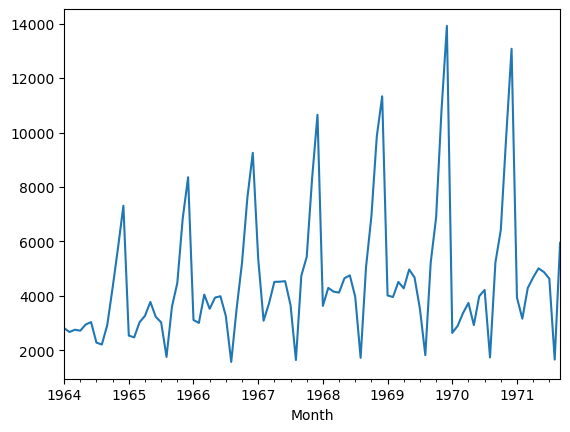

In [5]:
dataset.plot();

## Save and Plot Validation Set

Save the final 12 months to `data/validation.csv`, then plot it to confirm it represents one contiguous year of observations.

In [6]:
validation.to_csv('data/validation.csv')

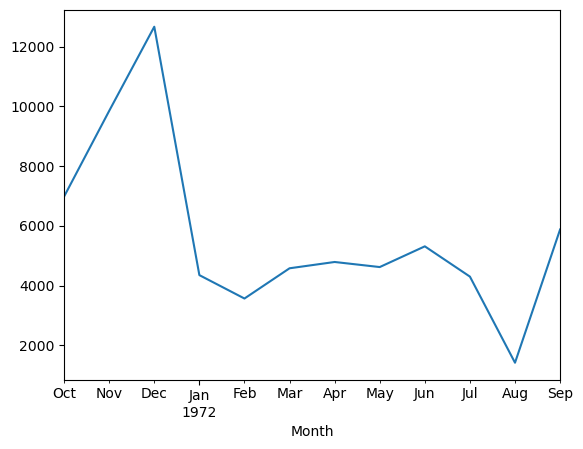

In [7]:
validation.plot();